In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
from lifelines import KaplanMeierFitter, WeibullAFTFitter, LogNormalAFTFitter

In [44]:
df = pd.read_csv("../data/fraud_censored.csv")
df.head()

,transaction_id,transaction_date,observed_through_date,transaction_amt,product_cd,card_type,card_category,days_to_report_or_censoring,reported_fraud,_true_is_fraud
0,3377127,2018-03-24,2018-04-17,31.177,C,visa,debit,24.0,0,0
1,3382889,2018-03-26,2018-04-17,97.000,W,mastercard,credit,22.0,0,0
2,3435950,2018-04-12,2018-04-17,58.950,W,mastercard,debit,5.0,0,0
3,3417959,2018-04-05,2018-04-17,864.000,W,visa,debit,12.0,0,0
4,3010732,2017-12-07,2018-04-17,117.000,W,visa,credit,131.0,0,0


In [45]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["observed_through_date"] = pd.to_datetime(df["observed_through_date"])
df["transaction_week"] = df["transaction_date"].dt.to_period("W")
df["cohort_age_days"] = (df["observed_through_date"] - df["transaction_date"]).dt.days

## Q1 — naive reported-fraud rate, overall and by weekly cohort

compute `reported_fraud.mean()` overall, then bucket by weekly `transaction_date` cohort and show the downward bias for recent cohorts. Do **not** touch `_true_is_fraud` yet — save the comparison for the end of Q1 only after you've computed the naive numbers.

In [46]:
df['reported_fraud'].mean()

np.float64(0.025875)

<Axes: xlabel='transaction_week'>

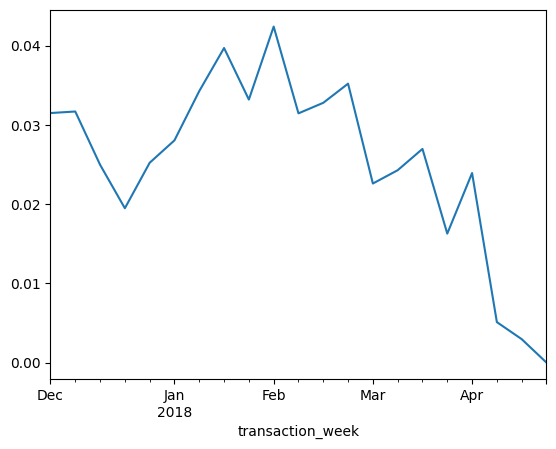

In [47]:
df.groupby('transaction_week')['reported_fraud'].mean().plot()

In [48]:
df['_true_is_fraud'].mean()

np.float64(0.035)

<Axes: xlabel='transaction_week'>

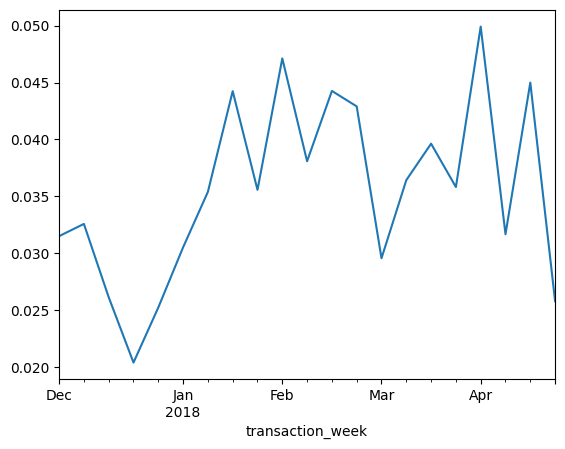

In [49]:
df.groupby('transaction_week')['_true_is_fraud'].mean().plot()

In [50]:
thresholds = range(7, 147, 7)  # weekly steps, in days

rows = {}
for week, cohort in df.groupby('transaction_week'):
    row = {}
    for t in thresholds:
        eligible = cohort[cohort['cohort_age_days'] >= t]
        if len(eligible) == 0:
            row[t] = np.nan
        else:
            row[t] = ((eligible['reported_fraud'] == 1) & (eligible['days_to_report_or_censoring'] <= t)).mean()
    rows[week] = row

triangle = pd.DataFrame(rows).T


<Axes: >

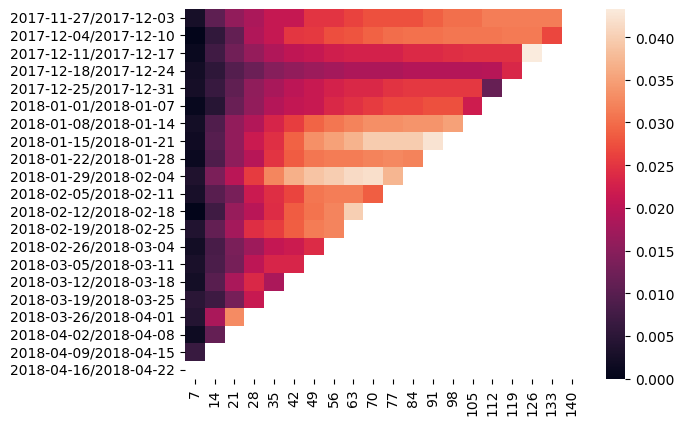

In [52]:
sns.heatmap(triangle)

<Axes: >

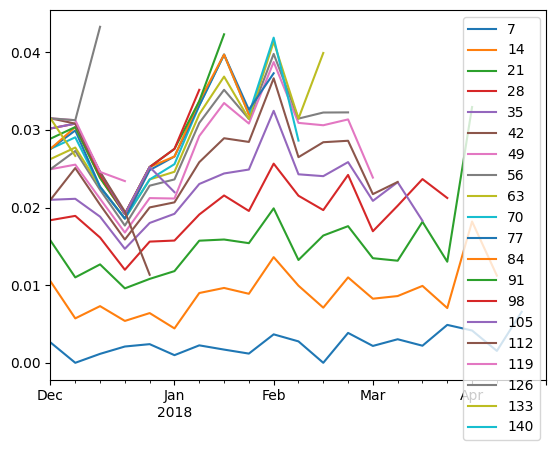

In [54]:
triangle.plot()

## Q2 — Kaplan-Meier and projected eventual reported-fraud rate

fit KM on `days_to_report_or_censoring` / `reported_fraud`, use it to project the eventual reported-fraud rate, and compare to the naive rate from Q1.

<Axes: xlabel='timeline'>

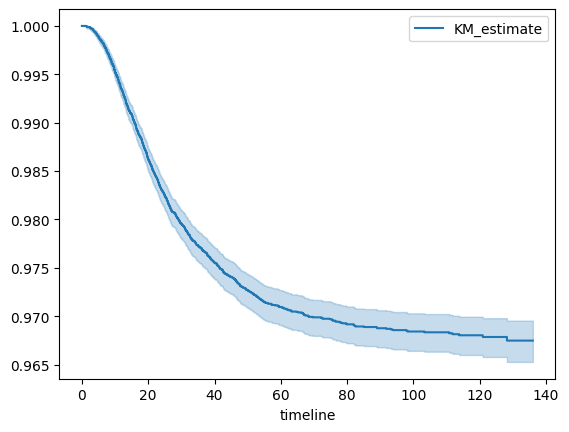

In [55]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df['days_to_report_or_censoring'], event_observed=df['reported_fraud'])

kmf.plot_survival_function()

In [56]:
projected_eventual_rate = 1 - kmf.survival_function_.iloc[-1, 0]
projected_eventual_rate

np.float64(0.032528100612680855)

## Q3 — Weibull / log-normal AFT on time-to-report

fit both, compare AIC/BIC, and interpret the fitted shape (early disputes vs. long tail).

In [57]:
# AFT models need strictly positive durations; KM tolerates 0 but Weibull/LogNormal don't.
# A handful of same-day transactions (transaction_date == observed_through_date) have duration 0.
df['duration_for_aft'] = df['days_to_report_or_censoring'].clip(lower=0.5)

In [58]:
weibull_aft = WeibullAFTFitter()
weibull_aft.fit(
    df[['duration_for_aft', 'reported_fraud']],
    duration_col='duration_for_aft',
    event_col='reported_fraud',
)
weibull_aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 40000 total observations, 38965 right-censored observations>
             duration col = 'duration_for_aft'
                event col = 'reported_fraud'
   number of observations = 40000
number of events observed = 1035
           log-likelihood = -9154.10
         time fit was run = 2026-08-17 03:36:24 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ Intercept  9.30  10932.60      0.15            9.01            9.59             8183.17            14605.82
rho_    Intercept -0.33      0.72      0.03           -0.39           -0.28                0.68                0.76

                   cmp to      z      p  -log2(p)
param   covariate                                
lambda_ Intercept    0.00  62.92 <0.005       inf
rho_    Intercept    0.00 -11.59 <0.005    100.74
---
Concordance = 0.50
AIC = 18312.19
log-likelihood ratio test = -0.00 on 0 df
-log2(p) of ll-ratio test = nan

In [59]:
lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(
    df[['duration_for_aft', 'reported_fraud']],
    duration_col='duration_for_aft',
    event_col='reported_fraud',
)
lognormal_aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 40000 total observations, 38965 right-censored observations>
             duration col = 'duration_for_aft'
                event col = 'reported_fraud'
   number of observations = 40000
number of events observed = 1035
           log-likelihood = -9094.23
         time fit was run = 2026-08-17 03:36:24 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                  
mu_    Intercept 10.69  43758.24      0.18           10.33           11.05            30554.88            62667.05
sigma_ Intercept  1.21      3.34      0.03            1.15            1.26                3.17                3.52

                  cmp to     z      p  -log2(p)
param  covariate                               
mu_    Intercept    0.00 58.32 <0.005       inf
sigma_ Intercept    0.00 44.89 <0.005       inf
---
Concordance = 0.50
AIC = 18192.47
log-likelihood ratio test = -0.00 on 0 df
-log2(p) of ll-ratio test = nan

In [60]:
print('Weibull AIC:', weibull_aft.AIC_)
print('Log-normal AIC:', lognormal_aft.AIC_)

Weibull AIC: 18312.190413359975
Log-normal AIC: 18192.46876098337


## Q4 — does `transaction_amt` or `product_cd` shift reporting time?

quantify with the AFT model's covariate effect.

In [61]:
product_dummies = pd.get_dummies(df['product_cd'], prefix='product', drop_first=True)
model_df = pd.concat(
    [df[['duration_for_aft', 'reported_fraud', 'transaction_amt']], product_dummies],
    axis=1,
)

lognormal_cov = LogNormalAFTFitter()
lognormal_cov.fit(model_df, duration_col='duration_for_aft', event_col='reported_fraud')
lognormal_cov.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 40000 total observations, 38965 right-censored observations>
             duration col = 'duration_for_aft'
                event col = 'reported_fraud'
   number of observations = 40000
number of events observed = 1035
           log-likelihood = -8814.33
         time fit was run = 2026-08-17 03:55:31 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                        
mu_    product_H        1.42      4.12      0.16            1.09            1.74                2.98                5.68
       product_R        2.14      8.54      0.19            1.78            2.51                5.92               12.30
       product_S        1.18      3.24      0.28            0.63            1.72                1.88                5.57
       product_W        2.58     13.20      0.13            2.34            2.83               10.33               16.88
       transaction_amt -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
       Intercept        8.74   6218.92      0.16            8.43            9.04             4582.50             8439.71
sigma_ Intercept        1.17      3.21      0.03            1.11            1.22                3.05                3.38

                        cmp to     z      p  -log2(p)
param  covariate                                     
mu_    product_H          0.00  8.60 <0.005     56.75
       product_R          0.00 11.50 <0.005     99.19
       product_S          0.00  4.25 <0.005     15.49
       product_W          0.00 20.61 <0.005    311.24
       transaction_amt    0.00 -7.90 <0.005     48.40
       Intercept          0.00 56.07 <0.005       inf
sigma_ Intercept          0.00 43.45 <0.005       inf
---
Concordance = 0.71
AIC = 17642.66
log-likelihood ratio test = 559.80 on 5 df
-log2(p) of ll-ratio test = 392.02

## Q5 — operational cutoff: expected eventual fraud rate for not-yet-flagged recent transactions

e.g. "transactions from the last 14 days" — conditional survival, the number a fraud team needs for staffing/reserve decisions.

## Q6 — answer key check (only after finishing 1–5)

compare KM-corrected and AFT-projected fraud rate estimates against `_true_is_fraud`. How close, and where does the estimate fall short?